# Sistema de predicción de riesgo de anemia infantil y segmentación de casos — San Martín, Perú

**Alumna:** Fátima Pacheco Antón

**Docente:** Ciro Rodriguez Rodriguez

**Curso:** Inteligencia Artificial

**Metodología:** CRISP-DM

Dataset real: `ANEMIA_DA.csv`, Plataforma Nacional de Datos Abiertos del Perú (MINSA), región San Martín.


In [3]:
pip install pandas numpy matplotlib seaborn scikit-learn

## 1. Carga y comprensión de los datos (CRISP-DM: Data Understanding)

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
pd.set_option("display.max_columns", 100)

# El portal de datos abiertos del Perú publica este CSV separado por ";"
df = pd.read_csv("ANEMIA_DA.csv", sep=";", encoding="utf-8-sig", low_memory=False)

print("Filas y columnas:", df.shape)
df.head()

Filas y columnas: (59225, 22)


,PK_REGISTRO,FECHA_REGISTRO,GENERO,EDAD_REGISTRO,TIPO_EDAD,ETNIA,F_ATENCION,GRADO_SEVERIDAD,DIAGNOSTICO,TIPO_DIAGNOSTICO,DESCRIPCION_FINANCIADOR,CANTIDAD,PROVINCIA,DEPARTAMENTO,DISTRITO,RED,MICRORED,NOMBRE_ESTABLECIMIENTO,CODIGO_UNICO,LONGITUD,LATITUD,FECHA_CORTE
0,1,20180810,M,5,A,Mestizo,20180810,MOD,ANEMIA POR DEFICIENCIA DE HIERRO SIN ESPECIFIC...,D,S.I.S,1,MARISCAL CACERES,SAN MARTIN,HUICUNGO,MARISCAL CACERES,HUICUNGO,PIZARRO,6571,-76.985172,-7.250180,20250424
1,2,20170406,M,3,A,Mestizo,20170406,LEV,ANEMIA POR DEFICIENCIA DE HIERRO SIN ESPECIFIC...,D,S.I.S,1,SAN MARTIN,SAN MARTIN,TARAPOTO,SAN MARTIN,TARAPOTO,HUAYCO TARAPOTO,6371,-76.367503,-6.502062,20250424
2,3,20180719,F,5,A,Mestizo,20180719,LEV,ANEMIA POR DEFICIENCIA DE HIERRO SIN ESPECIFIC...,D,S.I.S,1,EL DORADO,SAN MARTIN,SAN JOSE DE SISA,EL DORADO,SAN JOSE DE SISA,HOSPITAL RURAL SAN JOSE DE SISA,6485,-76.688596,-6.614755,20250424
3,4,20170912,M,4,A,Mestizo,20170912,LEV,ANEMIA POR DEFICIENCIA DE HIERRO SIN ESPECIFIC...,D,S.I.S,1,RIOJA,SAN MARTIN,RIOJA,RIOJA,NUEVO RIOJA,LA PERLA DE CASCAYUNGA,6708,-77.236470,-6.092303,20250424
4,5,20180718,F,5,A,Mestizo,20180718,LEV,ANEMIA POR DEFICIENCIA DE HIERRO SIN ESPECIFIC...,D,S.I.S,1,EL DORADO,SAN MARTIN,SAN JOSE DE SISA,EL DORADO,SAN JOSE DE SISA,HOSPITAL RURAL SAN JOSE DE SISA,6485,-76.688596,-6.614755,20250424


In [5]:
# Comprensión de los datos
print("Columnas:", df.columns.tolist())
print()
df.info()
print()
print("Valores nulos por columna:")
print(df.isna().sum())

Columnas: ['PK_REGISTRO', 'FECHA_REGISTRO', 'GENERO', 'EDAD_REGISTRO', 'TIPO_EDAD', 'ETNIA', 'F_ATENCION', 'GRADO_SEVERIDAD', 'DIAGNOSTICO', 'TIPO_DIAGNOSTICO', 'DESCRIPCION_FINANCIADOR', 'CANTIDAD', 'PROVINCIA', 'DEPARTAMENTO', 'DISTRITO', 'RED', 'MICRORED', 'NOMBRE_ESTABLECIMIENTO', 'CODIGO_UNICO', 'LONGITUD', 'LATITUD', 'FECHA_CORTE']

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 59225 entries, 0 to 59224
Data columns (total 22 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   PK_REGISTRO              59225 non-null  int64  
 1   FECHA_REGISTRO           59225 non-null  int64  
 2   GENERO                   59225 non-null  object 
 3   EDAD_REGISTRO            59225 non-null  int64  
 4   TIPO_EDAD                59225 non-null  object 
 5   ETNIA                    59225 non-null  object 
 6   F_ATENCION               59225 non-null  int64  
 7   GRADO_SEVERIDAD          59225 non-null  object 
 8   DIAGN

In [6]:
# DIVISIÓN DE DATOS
print(df["GRADO_SEVERIDAD"].value_counts())
print()
print("El dataset cubre una sola región:", df["DEPARTAMENTO"].unique())
print("Provincias distintas:", df["PROVINCIA"].nunique())
print("Rango de fechas de registro:", df["FECHA_REGISTRO"].min(), "-", df["FECHA_REGISTRO"].max())

GRADO_SEVERIDAD
LEV    46441
MOD    12523
SEV      246
lev       15
Name: count, dtype: int64

El dataset cubre una sola región: ['SAN MARTIN']
Provincias distintas: 10
Rango de fechas de registro: 20160101 - 20250426


## 2. Limpieza de datos (Data Cleaning)

In [7]:
df = df.drop_duplicates()

# GRADO_SEVERIDAD trae inconsistencias de mayúsculas/minúsculas ("LEV" y "lev")
df["GRADO_SEVERIDAD"] = df["GRADO_SEVERIDAD"].str.strip().str.upper()

# EDAD_REGISTRO viene en unidades distintas según TIPO_EDAD (A=años, M=meses, D=días).
# La estandarizamos a una sola unidad (meses) para poder comparar y modelar.
def a_meses(row):
    e, t = row["EDAD_REGISTRO"], row["TIPO_EDAD"]
    if t == "A":
        return e * 12
    elif t == "M":
        return e
    elif t == "D":
        return e / 30
    return np.nan

df["EDAD_MESES"] = df.apply(a_meses, axis=1)

# Se detectaron edades imposibles (negativas). Se descartan junto con
# edades mayores a 15 años (180 meses), fuera del rango de interés pediátrico.
antes = len(df)
df = df[(df["EDAD_MESES"] >= 0) & (df["EDAD_MESES"] <= 180)]
print(f"Filas descartadas por edad inválida: {antes - len(df)} de {antes}")

df["ANIO_REGISTRO"] = df["FECHA_REGISTRO"].astype(str).str.slice(0, 4).astype(int)

Filas descartadas por edad inválida: 4 de 59225


In [8]:
# Variable objetivo binaria para el Modelo 1:
# 0 = anemia leve, 1 = riesgo de severidad mayor (moderada o severa)
df["RIESGO_SEVERO"] = df["GRADO_SEVERIDAD"].isin(["MOD", "SEV"]).astype(int)
print(df["RIESGO_SEVERO"].value_counts(normalize=True).round(3))
# Nota: hay desbalance de clases (~78% leve vs ~22% riesgo severo),
# por eso más adelante se usa class_weight="balanced" y se mira F1, no solo Accuracy.

RIESGO_SEVERO
0    0.784
1    0.216
Name: proportion, dtype: float64


## 3. Análisis Exploratorio de Datos (EDA)

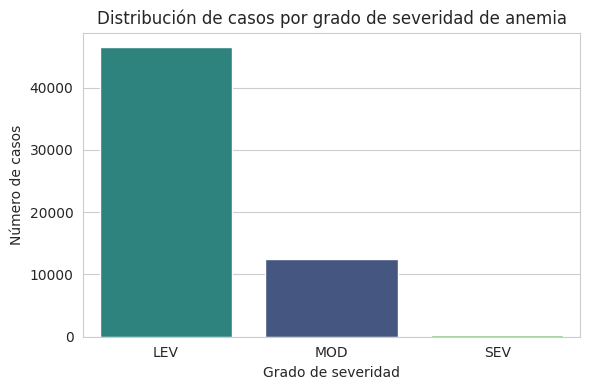

In [9]:
# Gráfico 1: distribución de la variable objetivo
plt.figure(figsize=(6,4))
orden = ["LEV", "MOD", "SEV"]
sns.countplot(data=df, x="GRADO_SEVERIDAD", order=orden, hue="GRADO_SEVERIDAD",
              palette="viridis", legend=False)
plt.title("Distribución de casos por grado de severidad de anemia")
plt.xlabel("Grado de severidad")
plt.ylabel("Número de casos")
plt.tight_layout()
plt.savefig("01_distribucion_severidad.png")
plt.show()
# Qué buscamos: confirmar el desbalance de clases, que justifica usar F1-score
# además de Accuracy al evaluar el Modelo 1.

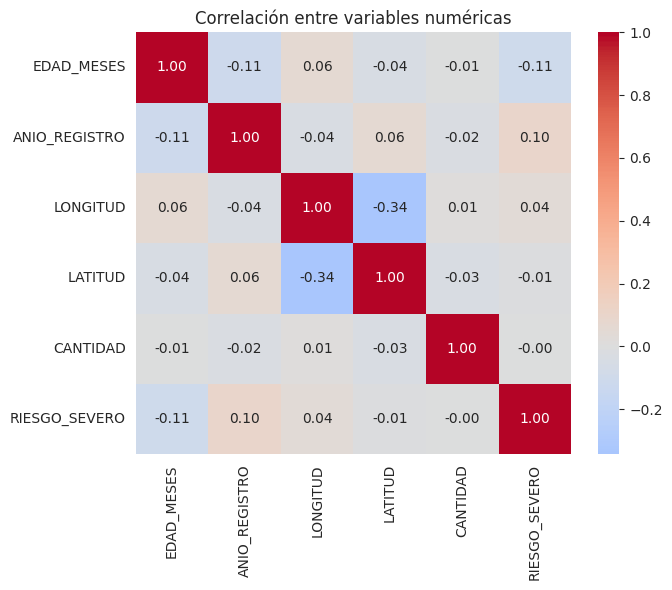

In [10]:
# Gráfico 2: mapa de calor de correlaciones
plt.figure(figsize=(7,6))
num_cols = ["EDAD_MESES", "ANIO_REGISTRO", "LONGITUD", "LATITUD", "CANTIDAD", "RIESGO_SEVERO"]
sns.heatmap(df[num_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlación entre variables numéricas")
plt.tight_layout()
plt.savefig("02_heatmap_correlacion.png")
plt.show()
# Qué buscamos: variables numéricas con relación con el riesgo de severidad, que orienten qué variables vale la pena mantener.

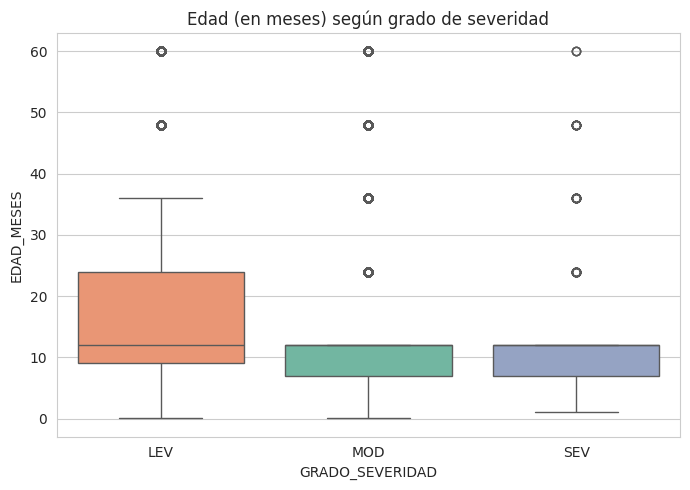

In [11]:
# Gráfico 3: edad vs. severidad
plt.figure(figsize=(7,5))
sns.boxplot(data=df, x="GRADO_SEVERIDAD", order=orden, y="EDAD_MESES",
            hue="GRADO_SEVERIDAD", palette="Set2", legend=False)
plt.title("Edad (en meses) según grado de severidad")
plt.tight_layout()
plt.savefig("03_edad_vs_severidad.png")
plt.show()
# Qué buscamos: si los casos más severos se concentran en un rango de edad
# distinto al de los casos leves (patrón esperado en menores de 3 años).

## 4. Codificación de variables e ingeniería de características

In [12]:
# Seleccionamos variables demográficas y geográficas como predictoras.
# Se descarta DEPARTAMENTO, DISTRITO
# y las columnas identificadoras (PK_REGISTRO, CODIGO_UNICO, NOMBRE_ESTABLECIMIENTO)
# que no aportan información predictiva real.
cols_modelo = ["EDAD_MESES", "GENERO", "ETNIA", "PROVINCIA", "RED",
               "DESCRIPCION_FINANCIADOR", "LONGITUD", "LATITUD", "ANIO_REGISTRO"]

df_model = df[cols_modelo + ["RIESGO_SEVERO", "GRADO_SEVERIDAD"]].copy()
df_model = pd.get_dummies(
    df_model,
    columns=["GENERO", "ETNIA", "PROVINCIA", "RED", "DESCRIPCION_FINANCIADOR"],
    drop_first=True
)

X = df_model.drop(columns=["RIESGO_SEVERO", "GRADO_SEVERIDAD"])
y = df_model["RIESGO_SEVERO"]
print("Variables predictoras finales:", X.shape[1])

Variables predictoras finales: 34


## 5. Prevención de Data Leakage: partición train / validación / test

In [13]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 60% train, 20% validación, 20% test, estratificado por la variable objetivo
# para mantener la misma proporción de riesgo severo en cada partición.
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.4, random_state=42, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

# El escalador se AJUSTA solo con train y luego se aplica (transform) a
# validación y test, para no filtrar información de esos conjuntos.
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_val_s = scaler.transform(X_val)
X_test_s = scaler.transform(X_test)

print("Train:", X_train.shape, " Val:", X_val.shape, " Test:", X_test.shape)

Train: (35532, 34)  Val: (11844, 34)  Test: (11845, 34)


## 6. Modelado: Baseline + 2 modelos complementarios

In [14]:
from sklearn.dummy import DummyClassifier

# Baseline: siempre predice la clase mayoritaria (leve)
baseline = DummyClassifier(strategy="most_frequent", random_state=42)
baseline.fit(X_train_s, y_train)
print("Baseline entrenado (predice siempre 'sin riesgo severo').")

Baseline entrenado (predice siempre 'sin riesgo severo').


In [15]:
from sklearn.linear_model import LogisticRegression

# Modelo 1: Regresión Logística (clasificación supervisada)
modelo1 = LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42)
modelo1.fit(X_train_s, y_train)
print("Modelo 1 (Regresión Logística) entrenado.")

Modelo 1 (Regresión Logística) entrenado.


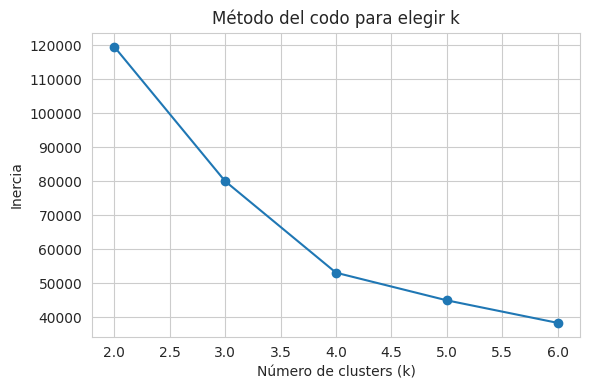

Silhouette por k: {2: np.float64(0.366), 3: np.float64(0.426), 4: np.float64(0.47), 5: np.float64(0.401), 6: np.float64(0.409)}


In [16]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Modelo 2: K-Means (clustering, no supervisado)
cols_cluster = ["EDAD_MESES", "LONGITUD", "LATITUD"]
scaler_cluster = StandardScaler()
Xc = scaler_cluster.fit_transform(df_model[cols_cluster])

# Método del codo para justificar la elección de k
inercias, siluetas = [], []
for k in range(2, 7):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(Xc)
    inercias.append(km.inertia_)
    siluetas.append(silhouette_score(Xc, labels))

plt.figure(figsize=(6,4))
plt.plot(range(2,7), inercias, marker="o")
plt.title("Método del codo para elegir k")
plt.xlabel("Número de clusters (k)")
plt.ylabel("Inercia")
plt.tight_layout()
plt.savefig("05_codo_kmeans.png")
plt.show()
print("Silhouette por k:", dict(zip(range(2,7), [round(s,3) for s in siluetas])))

In [17]:
# Se elige k=4
k_elegido = 4
modelo2_kmeans = KMeans(n_clusters=k_elegido, random_state=42, n_init=10)
df_model["CLUSTER"] = modelo2_kmeans.fit_predict(Xc)

sil_final = silhouette_score(Xc, df_model["CLUSTER"])
print(f"Modelo 2 (K-Means, k={k_elegido}) entrenado. Silhouette score: {sil_final:.3f}")

Modelo 2 (K-Means, k=4) entrenado. Silhouette score: 0.470


## 7. Evaluación rigurosa


In [18]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
)

def evaluar_clasificacion(model, Xs, y_true, nombre):
    pred = model.predict(Xs)
    acc = accuracy_score(y_true, pred)
    prec = precision_score(y_true, pred, zero_division=0)
    rec = recall_score(y_true, pred, zero_division=0)
    f1 = f1_score(y_true, pred, zero_division=0)
    cm = confusion_matrix(y_true, pred)
    print(f"--- {nombre} ---")
    print(f"Accuracy : {acc:.3f}")
    print(f"Precision: {prec:.3f}")
    print(f"Recall   : {rec:.3f}")
    print(f"F1-score : {f1:.3f}")
    print("Matriz de confusión:\n", cm)
    print()
    return acc, prec, rec, f1, cm

print("=== Validación ===")
evaluar_clasificacion(baseline, X_val_s, y_val, "Baseline")
evaluar_clasificacion(modelo1, X_val_s, y_val, "Modelo 1: Regresión Logística")

=== Validación ===
--- Baseline ---
Accuracy : 0.784
Precision: 0.000
Recall   : 0.000
F1-score : 0.000
Matriz de confusión:
 [[9290    0]
 [2554    0]]

--- Modelo 1: Regresión Logística ---
Accuracy : 0.567
Precision: 0.279
Recall   : 0.633
F1-score : 0.387
Matriz de confusión:
 [[5101 4189]
 [ 937 1617]]



(0.5672070246538332,
 0.27850499483293145,
 0.6331245105716523,
 0.3868421052631579,
 array([[5101, 4189],
        [ 937, 1617]]))

=== Test final (solo se corre una vez, al final) ===
--- Baseline — test ---
Accuracy : 0.784
Precision: 0.000
Recall   : 0.000
F1-score : 0.000
Matriz de confusión:
 [[9291    0]
 [2554    0]]

--- Modelo 1 — test ---
Accuracy : 0.554
Precision: 0.270
Recall   : 0.625
F1-score : 0.377
Matriz de confusión:
 [[4968 4323]
 [ 959 1595]]



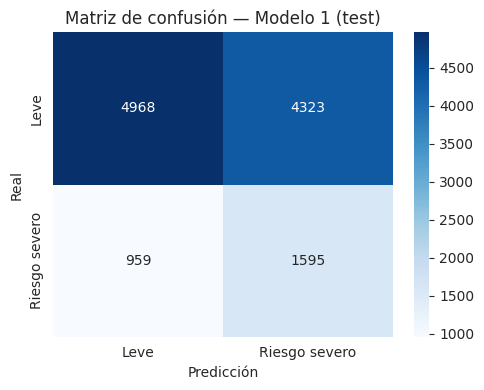

In [19]:
print("=== Test final (solo se corre una vez, al final) ===")
evaluar_clasificacion(baseline, X_test_s, y_test, "Baseline — test")
resultado_m1_test = evaluar_clasificacion(modelo1, X_test_s, y_test, "Modelo 1 — test")

plt.figure(figsize=(5,4))
sns.heatmap(resultado_m1_test[4], annot=True, fmt="d", cmap="Blues",
            xticklabels=["Leve", "Riesgo severo"],
            yticklabels=["Leve", "Riesgo severo"])
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.title("Matriz de confusión — Modelo 1 (test)")
plt.tight_layout()
plt.savefig("04_matriz_confusion_modelo1.png")
plt.show()

Silhouette score final: 0.47

Distribución de severidad (%) dentro de cada cluster:
GRADO_SEVERIDAD   LEV   MOD  SEV
CLUSTER                         
0                78.6  21.0  0.4
1                78.2  21.4  0.4
2                75.4  24.1  0.5
3                86.4  13.3  0.3


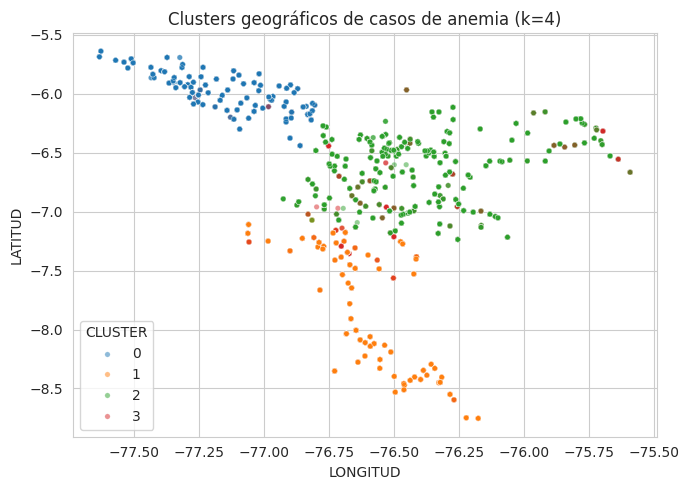

In [20]:
# Evaluación del Modelo 2 (K-Means)

crosstab = pd.crosstab(df_model["CLUSTER"], df_model["GRADO_SEVERIDAD"], normalize="index") * 100
print("Silhouette score final:", round(sil_final, 3))
print()
print("Distribución de severidad (%) dentro de cada cluster:")
print(crosstab.round(1))

plt.figure(figsize=(7,5))
sns.scatterplot(data=df_model, x="LONGITUD", y="LATITUD", hue="CLUSTER",
                 palette="tab10", alpha=0.5, s=15)
plt.title(f"Clusters geográficos de casos de anemia (k={k_elegido})")
plt.tight_layout()
plt.savefig("06_clusters_mapa.png")
plt.show()